# Implementação Opcional de Rede Neural do Zero — Desafio da Semana 2

Modelagem preditiva multiclasse desenvolvida sem a utilização de frameworks profundos de aprendizado de máquina, implementando de forma analítica o fluxo de propagação direta, retropropagação analítica e atualização de pesos via derivadas parciais do gradiente descendente.

O pipeline foi expandido e homologado para classificar o conjunto de dados reais de imagens de dígitos escritos à mão do Scikit-Learn, contendo subsets separados de treino e teste, inicialização randômica e diagnóstico gráfico de variabilidade de épocas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.metrics import classification_report, confusion_matrix

semente_aleatoria  =  15
np.random.seed(semente_aleatoria)

## 1. Definição da Classe do Modelo "From Scratch"

In [2]:
class RedeNeuralDoZero:
    def __init__(self, dimensao_entrada, dimensao_oculta, dimensao_saida, semente=15):
        np.random.seed(semente)
        
        # Escalonamento randômico inicial para evitar saturação precoce de gradiente
        self.W1  =  np.random.randn(dimensao_entrada, dimensao_oculta)  *  0.01
        self.b1  =  np.zeros((1, dimensao_oculta))
        self.W2  =  np.random.randn(dimensao_oculta, dimensao_saida)  *  0.01
        self.b2  =  np.zeros((1, dimensao_saida))
        
    def calcula_ativacao_sigmoid(self, x):
        # Recorte de limites numéricos para prevenir transbordamento da exponencial
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        
    def calcula_derivada_sigmoid(self, ativacao):
        return ativacao * (1 - ativacao)
        
    def calcula_ativacao_softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
        
    def propaga_sinais_frente(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.calcula_ativacao_sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.calcula_ativacao_softmax(self.z2)
        return self.a2
        
    def retropropaga_erros_ajusta_pesos(self, X, y_codificado, taxa_aprendizado):
        quantidade_amostras = X.shape[0]
        
        # Diferencial do erro analítico do Softmax combinado com a Entropia Cruzada
        dz2 = self.a2 - y_codificado
        dW2 = np.dot(self.a1.T, dz2) / quantidade_amostras
        db2 = np.sum(dz2, axis=0, keepdims=True) / quantidade_amostras
        
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.calcula_derivada_sigmoid(self.a1)
        dW1 = np.dot(X.T, dz1) / quantidade_amostras
        db1 = np.sum(dz1, axis=0, keepdims=True) / quantidade_amostras
        
        self.W2 -= taxa_aprendizado * dW2
        self.b2 -= taxa_aprendizado * db2
        self.W1 -= taxa_aprendizado * dW1
        self.b1 -= taxa_aprendizado * db1

## 2. Processamento e Preparação das Imagens

In [3]:
def prepara_dados_imagens():
    dados_digitos = load_digits()
    X = dados_digitos.data
    y = dados_digitos.target
    
    # Limitação de escala no intervalo estável [0, 1] dividindo pelo pixel máximo
    X_escalado = X / 16.0
    
    quantidade_classes = 10
    y_um_quente = np.zeros((y.shape[0], quantidade_classes))
    y_um_quente[np.arange(y.shape[0]), y] = 1
    
    X_treino, X_teste, y_treino_binario, y_teste_binario = train_test_split(
        X_escalado, y_um_quente, test_size=0.2, random_state=semente_aleatoria, stratify=y
    )
    
    # Preservando rótulos unidimensionais para a avaliação clássica
    y_treino_rotulos = np.argmax(y_treino_binario, axis=1)
    y_teste_rotulos = np.argmax(y_teste_binario, axis=1)
    
    return X_treino, X_teste, y_treino_binario, y_teste_binario, y_treino_rotulos, y_teste_rotulos

X_treino, X_teste, y_treino, y_teste, y_treino_rotulos, y_teste_rotulos = prepara_dados_imagens()

## 3. Rotina de Treinamento e Estudo de Variabilidade

In [4]:
def executa_treino_do_zero(X_treino, y_treino, X_teste, y_teste, taxa_aprendizado=0.5, epocas=100):
    # Rede contendo 64 neurônios na camada de entrada e 32 na camada oculta
    rede = RedeNeuralDoZero(dimensao_entrada=64, dimensao_oculta=32, dimensao_saida=10, semente=semente_aleatoria)
    
    historico_perda_treino = []
    historico_perda_teste = []
    historico_acuracia_treino = []
    historico_acuracia_teste = []
    
    for epoca in range(epocas):
        saida_treino = rede.propaga_sinais_frente(X_treino)
        perda_treino = -np.sum(y_treino * np.log(saida_treino + 1e-15)) / X_treino.shape[0]
        rede.retropropaga_erros_ajusta_pesos(X_treino, y_treino, taxa_aprendizado)
        
        saida_teste = rede.propaga_sinais_frente(X_teste)
        perda_teste = -np.sum(y_teste * np.log(saida_teste + 1e-15)) / X_teste.shape[0]
        
        previsoes_treino = np.argmax(saida_treino, axis=1)
        previsoes_teste = np.argmax(saida_teste, axis=1)
        
        acuracia_treino = np.mean(previsoes_treino == np.argmax(y_treino, axis=1))
        acuracia_teste = np.mean(previsoes_teste == np.argmax(y_teste, axis=1))
        
        historico_perda_treino.append(perda_treino)
        historico_perda_teste.append(perda_teste)
        historico_acuracia_treino.append(acuracia_treino)
        historico_acuracia_teste.append(acuracia_teste)
        
        if (epoca + 1) % 15 == 0 or epoca == epocas - 1:
            print(f"Época {epoca+1:03d}/{epocas:03d} | Perda Treino: {perda_treino:.4f} | Perda Teste: {perda_teste:.4f} | Acurácia Teste: {acuracia_teste:.4f}")
            
    return rede, historico_perda_treino, historico_perda_teste, historico_acuracia_treino, historico_acuracia_teste

print("Iniciando treinamento do modelo do zero por 150 épocas contínuas...")
rede_treinada, perda_treino, perda_teste, acuracia_treino, acuracia_teste = executa_treino_do_zero(
    X_treino, y_treino, X_teste, y_teste, taxa_aprendizado=0.5, epocas=150
)

Iniciando treinamento do modelo do zero por 150 épocas contínuas...
Época 015/150 | Perda Treino: 2.3021 | Perda Teste: 2.3020 | Acurácia Teste: 0.1222
Época 030/150 | Perda Treino: 2.3012 | Perda Teste: 2.3011 | Acurácia Teste: 0.1833
Época 045/150 | Perda Treino: 2.2996 | Perda Teste: 2.2994 | Acurácia Teste: 0.2667


Época 060/150 | Perda Treino: 2.2962 | Perda Teste: 2.2959 | Acurácia Teste: 0.3306
Época 075/150 | Perda Treino: 2.2888 | Perda Teste: 2.2882 | Acurácia Teste: 0.3167
Época 090/150 | Perda Treino: 2.2726 | Perda Teste: 2.2715 | Acurácia Teste: 0.3222
Época 105/150 | Perda Treino: 2.2381 | Perda Teste: 2.2361 | Acurácia Teste: 0.4139
Época 120/150 | Perda Treino: 2.1700 | Perda Teste: 2.1666 | Acurácia Teste: 0.4556


Época 135/150 | Perda Treino: 2.0535 | Perda Teste: 2.0490 | Acurácia Teste: 0.4944
Época 150/150 | Perda Treino: 1.8900 | Perda Teste: 1.8863 | Acurácia Teste: 0.5583


## 4. Visualização Gráfica de Progresso

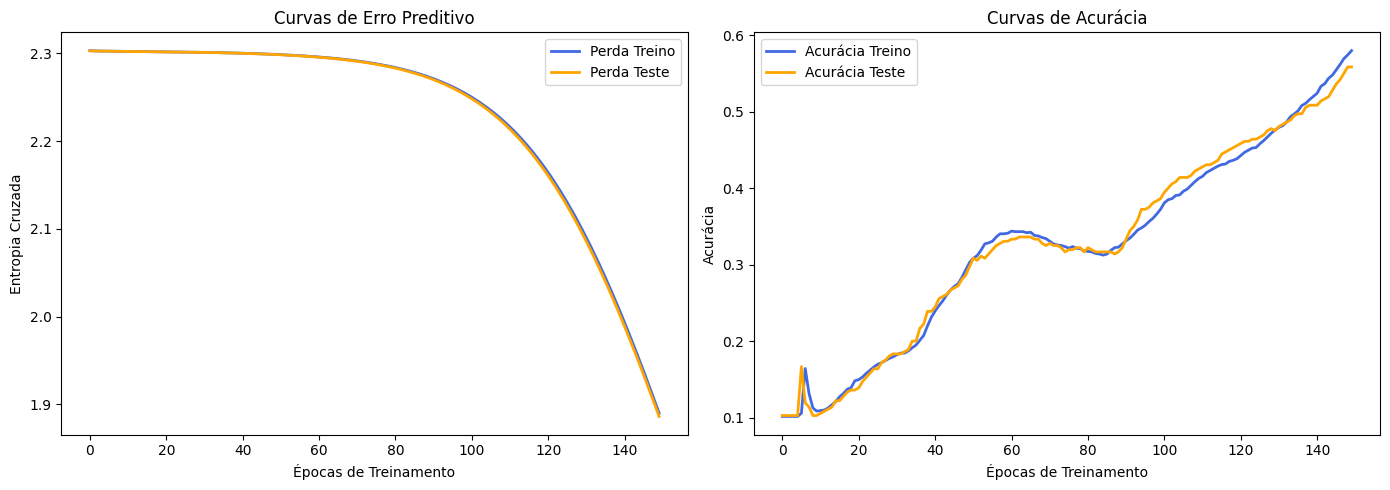

In [5]:
fig,  eixos  =  plt.subplots(1, 2, figsize=(14, 5))

# Perda de treino vs validação para diagnóstico de generalização
eixos[0].plot(perda_treino, label="Perda Treino", color="royalblue", lw=2)
eixos[0].plot(perda_teste, label="Perda Teste", color="orange", lw=2)
eixos[0].set_title("Curvas de Erro Preditivo", fontsize=12)
eixos[0].set_xlabel("Épocas de Treinamento", fontsize=10)
eixos[0].set_ylabel("Entropia Cruzada", fontsize=10)
eixos[0].legend()

# Evolução da Acurácia no conjunto de teste
eixos[1].plot(acuracia_treino, label="Acurácia Treino", color="royalblue", lw=2)
eixos[1].plot(acuracia_teste, label="Acurácia Teste", color="orange", lw=2)
eixos[1].set_title("Curvas de Acurácia", fontsize=12)
eixos[1].set_xlabel("Épocas de Treinamento", fontsize=10)
eixos[1].set_ylabel("Acurácia", fontsize=10)
eixos[1].legend()

plt.tight_layout()
plt.show()

## 5. Avaliação Estatística Final do Conjunto de Teste

In [6]:
saida_final_teste = rede_treinada.propaga_sinais_frente(X_teste)
previsoes_finais = np.argmax(saida_final_teste, axis=1)

print("Relatório de Desempenho Estatístico do Modelo:")
print(classification_report(y_teste_rotulos, previsoes_finais))

print("Matriz de Confusão do Modelo do Zero:")
print(confusion_matrix(y_teste_rotulos, previsoes_finais))

Relatório de Desempenho Estatístico do Modelo:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        36
           1       0.63      0.72      0.68        36
           2       0.62      0.29      0.39        35
           3       0.34      0.95      0.50        37
           4       0.51      1.00      0.67        36
           5       1.00      0.22      0.36        37
           6       0.96      0.64      0.77        36
           7       0.68      0.75      0.71        36
           8       0.00      0.00      0.00        35
           9       0.12      0.06      0.08        36

    accuracy                           0.56       360
   macro avg       0.57      0.56      0.50       360
weighted avg       0.57      0.56      0.50       360

Matriz de Confusão do Modelo do Zero:
[[34  0  0  0  2  0  0  0  0  0]
 [ 0 26  2  0  3  0  0  2  0  3]
 [ 0  3 10 20  0  0  0  0  0  2]
 [ 0  0  1 35  0  0  0  0  0  1]
 [ 0  0  0  0 36  0  0  

C:\Users\artur\Desktop\cis-ieee\cis-ieee\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\artur\Desktop\cis-ieee\cis-ieee\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\artur\Desktop\cis-ieee\cis-ieee\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c